<a href="https://colab.research.google.com/github/NehaSontakk/KEGG_GRAPH/blob/main/KO_graph_from_expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entering parse_expr at token: (
  Entering parse_sum_expr at token: (
    Entering parse_mult_expr at token: (
      Entering parse_factor at token: (
        Matched "(", current token: (
        Entering parse_expr at token: (
          Entering parse_sum_expr at token: (
            Entering parse_mult_expr at token: (
              Entering parse_factor at token: (
                Matched "(", current token: (
                Entering parse_expr at token: (
                  Entering parse_sum_expr at token: (
                    Entering parse_mult_expr at token: (
                      Entering parse_factor at token: (
                        Matched "(", current token: K01657
                        Entering parse_expr at token: K01657
                          Entering parse_sum_expr at token: K01657
                            Entering parse_mult_expr at token: K01657
                              Entering parse_factor at token: K01657
                                Creating 

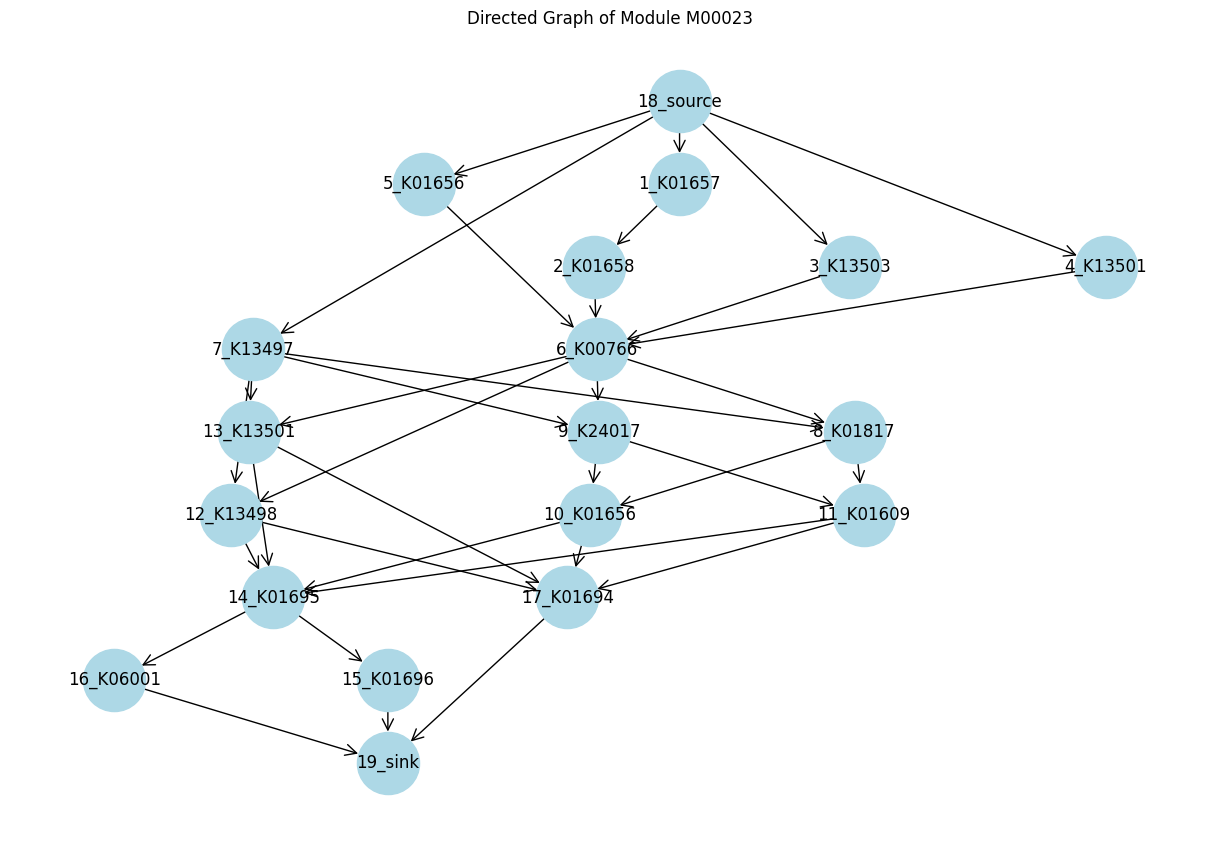

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

class Node:
    node_counter = 1  # Class variable for unique node IDs

    def __init__(self, name):
        self.name = name
        self.id = Node.node_counter
        Node.node_counter += 1

    def __repr__(self):
        return f"{self.id}_{self.name}"

# Global variables
nodes = []   # List of all Node objects
edges = []   # List of edges as tuples (from_node, to_node)
tokens = []
current_token_index = 0
indent_level = 0  # For tracking indentation in print statements

def tokenize(input_string):
    tokens = []
    i = 0
    while i < len(input_string):
        c = input_string[i]
        if c.isalnum():
            start = i
            while i < len(input_string) and input_string[i].isalnum():
                i += 1
            tokens.append(input_string[start:i])
        elif c in "+,() ":
            tokens.append(c)
            i += 1
        else:
            i += 1
    return tokens

def current_token():
    if current_token_index < len(tokens):
        return tokens[current_token_index]
    else:
        return None

def match(token_value):
    global current_token_index
    if current_token() == token_value:
        current_token_index += 1
        return True
    else:
        return False

def expect(token_value):
    if match(token_value):
        return True
    else:
        raise Exception(f"Expected '{token_value}' but found '{current_token()}'")

def consume_token():
    global current_token_index
    current_token_index += 1

def create_node(name):
    node = Node(name)
    nodes.append(node)
    return node

def create_edges(from_nodes, to_nodes):
    for from_node in from_nodes:
        for to_node in to_nodes:
            edges.append((from_node, to_node))

def parse_expr():
    global indent_level
    print('  ' * indent_level + f'Entering parse_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_sum_expr()
    while match(" "):
        print('  ' * indent_level + f'Matched space, current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_sum_expr()
        create_edges(last_nodes, next_top_nodes)
        print('  ' * indent_level + f'Created edges from {last_nodes} to {next_top_nodes}')
        last_nodes = next_last_nodes
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_sum_expr():
    global indent_level
    print('  ' * indent_level + f'Entering parse_sum_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_mult_expr()
    while match(","):
        print('  ' * indent_level + f'Matched ",", current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_mult_expr()
        top_nodes.extend(next_top_nodes)
        last_nodes.extend(next_last_nodes)
        print('  ' * indent_level + f'Combined top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_sum_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_mult_expr():
    global indent_level
    print('  ' * indent_level + f'Entering parse_mult_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_factor()
    while match("+"):
        print('  ' * indent_level + f'Matched "+", current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_mult_expr()
        create_edges(last_nodes, next_top_nodes)
        print('  ' * indent_level + f'Created edges from {last_nodes} to {next_top_nodes}')
        last_nodes = next_last_nodes  # Update last_nodes
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_mult_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_factor():
    global indent_level
    print('  ' * indent_level + f'Entering parse_factor at token: {current_token()}')
    indent_level += 1
    if match("("):
        print('  ' * indent_level + f'Matched "(", current token: {current_token()}')
        top_nodes, last_nodes = parse_expr()
        expect(")")
        print('  ' * indent_level + f'Expecting ")", current token: {current_token()}')
    elif current_token() is not None and current_token()[0].isalnum():
        token_name = current_token()
        print('  ' * indent_level + f'Creating node for token: {token_name}')
        consume_token()
        node = create_node(token_name)
        top_nodes = [node]
        last_nodes = [node]
    else:
        raise Exception(f"Unexpected token: {current_token()}")
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_factor with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def build_graph(input_string):
    global tokens, current_token_index, nodes, edges, indent_level
    tokens = tokenize(input_string)
    current_token_index = 0
    nodes = []
    edges = []
    indent_level = 0
    parse_expr()

    # Add "source" and "sink" nodes
    source_node = Node("source")
    sink_node = Node("sink")
    nodes.extend([source_node, sink_node])

    # Determine nodes with no incoming edges
    node_incoming = {node: 0 for node in nodes}
    node_outgoing = {node: 0 for node in nodes}
    for from_node, to_node in edges:
        node_incoming[to_node] = node_incoming.get(to_node, 0) + 1
        node_outgoing[from_node] = node_outgoing.get(from_node, 0) + 1

    # Add edges from "source" to nodes with no incoming edges
    for node in nodes:
        if node_incoming.get(node, 0) == 0 and node != source_node and node != sink_node:
            edges.append((source_node, node))

    # Add edges from nodes with no outgoing edges to "sink"
    for node in nodes:
        if node_outgoing.get(node, 0) == 0 and node != source_node and node != sink_node:
            edges.append((node, sink_node))

    return nodes, edges

def visualize_graph(nodes, edges):
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(str(node))
    for edge in edges:
        if len(edge) == 3:
            from_node, to_node, label = edge
            G.add_edge(str(from_node), str(to_node), label=label)
        else:
            from_node, to_node = edge
            G.add_edge(str(from_node), str(to_node))

    # Use Graphviz's 'dot' layout
    pos = nx.nx_pydot.graphviz_layout(G, prog='dot')

    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', arrows=True, arrowstyle='->', arrowsize=20)

    # Draw edge labels if any
    edge_labels = nx.get_edge_attributes(G, 'label')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Directed Graph of Module M00023")
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    input_string = "(((K01657+K01658,K13503,K13501,K01656) K00766),K13497) (((K01817,K24017) (K01656,K01609)),K13498,K13501) (K01695+(K01696,K06001),K01694)"
    nodes, edges = build_graph(input_string)

    # Print the nodes
    print("\nNodes:")
    for node in nodes:
        print(f"- {node}")

    # Print the edges
    print("\nEdges:")
    for from_node, to_node in edges:
        print(f"{from_node} -> {to_node}")

    visualize_graph(nodes, edges)
